##### Error-Mitigated QSVM (ZNE + REM) - Lung Cancer Dataset (Specific Parameters)

In [1]:
import qiskit, qiskit_aer, qiskit_machine_learning
print("Qiskit:", qiskit.__version__)
print("Aer:", qiskit_aer.__version__)
print("QML:", qiskit_machine_learning.__version__)

Qiskit: 2.2.3
Aer: 0.17.2
QML: 0.9.0


In [2]:
# Standard imports
import pandas as pd
import numpy as np
import time
import os
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, accuracy_score, balanced_accuracy_score, 
    recall_score, precision_score, f1_score
)
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

In [3]:
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [4]:
# --- Qiskit Imports ---
from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel

#### Data Loading

In [5]:
# Load lung cancer data
lung_cancer_column_names = ['label'] + [f'attr_{i}' for i in range(1, 57)]
file_path_lung = r'C:\Users\User\Documents\MyProjects\FYP_ResearchProject\data\lung+cancer\lung-cancer.data'
# file_path_lung = '/kaggle/input/lungcancer-qsvm/lung-cancer.data'

df_lung = pd.read_csv(file_path_lung, header=None, names=lung_cancer_column_names, na_values=['?'])
print(f"Original shape: {df_lung.shape}")

Original shape: (32, 57)


#### Data Preprocessing

In [6]:
# ==========================================
# PREPROCESSING (DO ONCE BEFORE LOOP)
# ==========================================

print("\n" + "="*80)
print("LUNG CANCER DATASET - ERROR MITIGATED QSVM (ZNE + REM)")
print("="*80)
print(f"Original shape of Lung Cancer data: {df_lung.shape}")

# --- Handling Missing Values ---
print("\n--- Handling Missing Values ---")
print(f"Total missing values before imputation: {df_lung.isnull().sum().sum()}")

for col in df_lung.columns:
    if df_lung[col].isnull().any():
        mode_val = df_lung[col].mode()[0]
        df_lung[col].fillna(mode_val, inplace=True)
        print(f"  Imputed column '{col}' with mode: {mode_val}")

print(f"Missing values after imputation: {df_lung.isnull().sum().sum()}")


LUNG CANCER DATASET - ERROR MITIGATED QSVM (ZNE + REM)
Original shape of Lung Cancer data: (32, 57)

--- Handling Missing Values ---
Total missing values before imputation: 5
  Imputed column 'attr_4' with mode: 1.0
  Imputed column 'attr_38' with mode: 2.0
Missing values after imputation: 0


In [7]:
# Binary label encoding
df_lung['label_binary'] = df_lung['label'].apply(lambda x: 0 if x == 1 else 1)

print(f"\nLabel distribution:")
print(df_lung['label_binary'].value_counts())


Label distribution:
label_binary
1    23
0     9
Name: count, dtype: int64


#### Noise Model Factory with Scaling (for ZNE)

In [8]:
# Base error rates (realistic NISQ device)
NOISE_CONFIGS = {
    'low': {'p_1q': 0.0001, 'p_2q': 0.001, 'p_ro': 0.002},
    'standard': {'p_1q': 0.001,  'p_2q': 0.01,  'p_ro': 0.02},
    'high': {'p_1q': 0.005,  'p_2q': 0.05,  'p_ro': 0.10}
}

def get_scaled_noise_model(scale_factor=1.0, level='standard'):
    """
    Build a noise model with scaled error probabilities for ZNE.
    Uses formula: p_scaled = 1 - (1-p)^scale_factor
    """
    config = NOISE_CONFIGS.get(level, NOISE_CONFIGS['standard'])
    
    p_1q = config['p_1q']
    p_2q = config['p_2q']
    p_ro = config['p_ro']

    p_1q_scaled = 1 - (1 - p_1q)**scale_factor
    p_2q_scaled = 1 - (1 - p_2q)**scale_factor
    p_ro_scaled = 1 - (1 - p_ro)**scale_factor
    
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_1q_scaled, 1), ['u1', 'u2', 'u3'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_2q_scaled, 2), ['cx'])
    readout_error = ReadoutError([[1 - p_ro_scaled, p_ro_scaled], [p_ro_scaled, 1 - p_ro_scaled]])
    noise_model.add_all_qubit_readout_error(readout_error)
    
    backend = AerSimulator(noise_model=noise_model, seed_simulator=12345)
    pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
    
    return noise_model, backend, pm, config

print("Noise model factory function ready!")
print("Available levels: 'low', 'standard', 'high'")

Noise model factory function ready!
Available levels: 'low', 'standard', 'high'


#### Readout Error Mitigation (REM) Function

In [9]:
# ==========================================
# READOUT ERROR MITIGATION (REM) FUNCTION
# ==========================================

def apply_rem_to_kernel(kernel_matrix, p_ro, n_qubits):
    """
    Apply Readout Error Mitigation to a kernel matrix.
    
    The correction formula for fidelity with symmetric readout error:
    K_corrected = (K_noisy - bias) / correction_factor
    """
    correction_factor = (1 - 2 * p_ro) ** n_qubits
    
    if abs(correction_factor) < 1e-10:
        print("Warning: Correction factor too small, using raw kernel")
        return kernel_matrix
    
    bias = 0.5 * (1 - correction_factor)
    corrected_kernel = (kernel_matrix - bias) / correction_factor
    
    # Clip to valid kernel range [0, 1]
    corrected_kernel = np.clip(corrected_kernel, 0, 1)
    
    # Ensure diagonal is exactly 1 (self-similarity)
    if kernel_matrix.shape[0] == kernel_matrix.shape[1]:
        np.fill_diagonal(corrected_kernel, 1.0)
    
    return corrected_kernel

print("REM function ready!")

REM function ready!


#### Experiment Configurations

In [10]:
# ==========================================
# EXPERIMENT CONFIGURATIONS (ZNE+REM COMBINED)
# ==========================================
# Note: Lung cancer has only 32 samples, so we use all of them
# Parameters adapted for small dataset

n_features_list = [5]
shots_list = [4096]
reps_list = [1]
entanglement_list = ['full']
noise_levels = ['low', 'standard', 'high']

em_experiments = []
for n_feat in n_features_list:
    for shot in shots_list:
        for rep in reps_list:
            for ent in entanglement_list:
                for noise in noise_levels:
                    em_experiments.append({
                        'id': f'EM_f{n_feat}_s{shot}_r{rep}_{ent}_{noise}',
                        'n_features': n_feat,
                        'shots': shot,
                        'reps': rep,
                        'entanglement': ent,
                        'noise_level': noise
                    })

print(f"Total error-mitigated experiments: {len(em_experiments)}")
# 9 × 3 × 2 × 3 × 3 = 486 experiments

Total error-mitigated experiments: 3


#### Main Experiment Loop (ZNE + REM)

In [11]:
# ==========================================
# MAIN EXPERIMENT LOOP - ERROR MITIGATED LUNG CANCER (ZNE + REM)
# ==========================================

# Setup kernel directory
kernel_dir = 'kernels_em_znerem_lungcancer'
os.makedirs(kernel_dir, exist_ok=True)

# ZNE scales for Richardson extrapolation
ZNE_SCALES = [1.0, 3.0]

# Store all results
all_results = []

# Separate Features & Target (MATCH NOISY NOTEBOOK)
X_lung = df_lung.drop(['label', 'label_binary'], axis=1)
y_lung_binary = df_lung['label_binary']

# Loop over experiments
for exp_num, config in enumerate(em_experiments, 1):
    print("\n" + "=" * 80)
    print(f"EXPERIMENT {exp_num}/{len(em_experiments)}: {config['id']}")
    print("=" * 80)
    print(f"  Number of Features: {config['n_features']}")
    print(f"  Shots: {config['shots']}")
    print(f"  Reps: {config['reps']}")
    print(f"  Entanglement: {config['entanglement']}")
    print(f"  Noise Level: {config['noise_level']}")
    print("=" * 80)
    
    # Check for cached kernels
    train_file_scale1 = f'{kernel_dir}/kernel_train_scale1_{config["id"]}.npy'
    test_file_scale1 = f'{kernel_dir}/kernel_test_scale1_{config["id"]}.npy'
    train_file_scale3 = f'{kernel_dir}/kernel_train_scale3_{config["id"]}.npy'
    test_file_scale3 = f'{kernel_dir}/kernel_test_scale3_{config["id"]}.npy'
    
    skip_quantum = (os.path.exists(train_file_scale1) and 
                    os.path.exists(test_file_scale1) and
                    os.path.exists(train_file_scale3) and 
                    os.path.exists(test_file_scale3))

    # ===================================================================
    # 1. TRAIN-TEST SPLIT (MATCH NOISY: 70-30)
    # ===================================================================
    
    X_train_lc, X_test_lc, y_train_lc, y_test_lc = train_test_split(
        X_lung, y_lung_binary, test_size=0.3, random_state=42, stratify=y_lung_binary
    )

    print(f"\nDataset created: {X_train_lc.shape[0]} train, {X_test_lc.shape[0]} test")

    # ===================================================================
    # 2. ONE-HOT ENCODING (LUNG CANCER SPECIFIC)
    # ===================================================================
    
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_train_lc_encoded = pd.DataFrame(
        encoder.fit_transform(X_train_lc),
        columns=encoder.get_feature_names_out()
    )
    X_test_lc_encoded = pd.DataFrame(
        encoder.transform(X_test_lc),
        columns=encoder.get_feature_names_out()
    )

    print("Data encoded successfully")

    # ===================================================================
    # 3. FEATURE SELECTION - CRAMÉR'S V (LUNG CANCER SPECIFIC)
    # ===================================================================
    print("\n--- Feature Selection ---")
    
    def cramers_v(x, y):
        confusion_matrix = pd.crosstab(x, y)
        chi2 = chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        phi2 = chi2 / n
        r, k = confusion_matrix.shape
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
        rcorr = r - ((r-1)**2)/(n-1)
        kcorr = k - ((k-1)**2)/(n-1)
        if min((kcorr-1), (rcorr-1)) == 0: 
            return 0
        return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
    
    cramers_scores = {col: cramers_v(X_train_lc_encoded[col], y_train_lc) 
                      for col in X_train_lc_encoded.columns}
    cramers_series = pd.Series(cramers_scores).sort_values(ascending=False)
    
    n_features = config['n_features']  
    top_features = cramers_series.head(n_features).index.tolist()
    print(f"Top {n_features} features selected:")
    print(top_features)
    
    # Create the final datasets with only the selected features
    X_train_final = X_train_lc_encoded[top_features].values * np.pi
    X_test_final = X_test_lc_encoded[top_features].values * np.pi
    
    print(f"\nFinal training data shape: {X_train_final.shape}")
    print(f"Final testing data shape: {X_test_final.shape}\n")
    
    # Store for results
    selected_features = top_features
    n_features_selected = len(selected_features)

    # ===================================================================
    # 4. COMPUTE OR LOAD QUANTUM KERNELS (ZNE SCALES)
    # ===================================================================
    
    noise_level = config['noise_level']
    kernel_time = 0
    
    if skip_quantum:
        print(f"Loading cached kernels (scales 1.0 & 3.0)...")
        kernels_train = {
            1.0: np.load(train_file_scale1),
            3.0: np.load(train_file_scale3)
        }
        kernels_test = {
            1.0: np.load(test_file_scale1),
            3.0: np.load(test_file_scale3)
        }
        print(f"  → Loaded from {kernel_dir}/")
    else:
        print(f"Computing quantum kernels at ZNE scales {ZNE_SCALES}...")
        
        # Get noise parameters
        noise_config = NOISE_CONFIGS.get(noise_level, NOISE_CONFIGS['standard'])
        print(f"Noise Model: 1q={noise_config['p_1q']*100:.2f}%, 2q={noise_config['p_2q']*100:.2f}%, readout={noise_config['p_ro']*100:.2f}%")
        
        kernels_train = {}
        kernels_test = {}
        
        # Create feature map
        fm = ZZFeatureMap(
            feature_dimension=n_features,
            reps=int(config['reps']),
            entanglement=config['entanglement']
        )
        
        print(f"Noisy quantum kernel configured (ZZFeatureMap, reps={config['reps']}, entanglement={config['entanglement']}, noise={noise_level})")
        
        print("\nComputing kernel matrices...")
        start_kernel = time.time()
        
        for scale in ZNE_SCALES:
            print(f"  → Computing kernels at noise scale {scale}...")
            _, backend, pm, _ = get_scaled_noise_model(scale_factor=scale, level=noise_level)
            sampler = AerSampler.from_backend(backend=backend, default_shots=int(config['shots']))
            fidelity = ComputeUncompute(sampler=sampler, pass_manager=pm)
            qkernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=fm)
            
            kernels_train[scale] = qkernel.evaluate(x_vec=X_train_final)
            kernels_test[scale] = qkernel.evaluate(x_vec=X_test_final, y_vec=X_train_final)
        
        kernel_time = time.time() - start_kernel
        print(f"Kernel computation: {kernel_time:.2f}s")
        
        # Save kernels for future use
        np.save(train_file_scale1, kernels_train[1.0])
        np.save(test_file_scale1, kernels_test[1.0])
        np.save(train_file_scale3, kernels_train[3.0])
        np.save(test_file_scale3, kernels_test[3.0])
        print(f"Saved kernel matrices to {kernel_dir}/")

    # ===================================================================
    # 5. ERROR MITIGATION (ZNE + REM)
    # ===================================================================
    
    print(f"\nApplying Error Mitigation (ZNE + REM)...")
    
    # Get noise config for REM
    noise_config = NOISE_CONFIGS.get(noise_level, NOISE_CONFIGS['standard'])
    p_ro = noise_config['p_ro']
    n_qubits = n_features
    
    # Step 1: ZNE (Linear Richardson extrapolation)
    print(f"  → Step 1: Zero-Noise Extrapolation (Richardson)")
    kernel_train_zne = 1.5 * kernels_train[1.0] - 0.5 * kernels_train[3.0]
    kernel_test_zne = 1.5 * kernels_test[1.0] - 0.5 * kernels_test[3.0]
    
    # Step 2: REM (Readout error mitigation)
    print(f"  → Step 2: Readout Error Mitigation (p_ro={p_ro:.4f}, n_qubits={n_qubits})")
    K_train = apply_rem_to_kernel(kernel_train_zne, p_ro, n_qubits)
    K_test = apply_rem_to_kernel(kernel_test_zne, p_ro, n_qubits)
    
    # Ensure validity
    K_train = np.clip(K_train, 0, 1)
    K_test = np.clip(K_test, 0, 1)
    print(f"Error mitigation complete!")

    # ===================================================================
    # 6. GRID SEARCH (MATCH NOISY: BALANCED_ACCURACY)
    # ===================================================================
    
    print(f"\nGrid searching for optimal hyperparameters...")
    
    param_grid = {'C': [100]}
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    grid_search = GridSearchCV(
        SVC(kernel='precomputed', class_weight='balanced'),
        param_grid,
        cv=cv,
        scoring='balanced_accuracy',
        n_jobs=-1,
        verbose=0
    )
    
    start_train = time.time()
    grid_search.fit(K_train, y_train_lc.values)
    train_time = time.time() - start_train
    
    best_model = grid_search.best_estimator_
    best_c = grid_search.best_params_['C']
    cv_score = grid_search.best_score_
    
    print(f"  → Best C: {best_c}")
    print(f"  → CV Score: {cv_score:.4f}")
    print(f"  → Training time: {train_time:.2f}s")

    # ===================================================================
    # 7. EVALUATION (MATCH NOISY METRICS)
    # ===================================================================
    
    y_train_pred = best_model.predict(K_train)
    y_test_pred = best_model.predict(K_test)

    train_acc = accuracy_score(y_train_lc, y_train_pred)
    test_acc = accuracy_score(y_test_lc, y_test_pred)
    test_balanced_acc = balanced_accuracy_score(y_test_lc, y_test_pred)
    precision = precision_score(y_test_lc, y_test_pred, zero_division=0)
    recall = recall_score(y_test_lc, y_test_pred, zero_division=0)
    f1 = f1_score(y_test_lc, y_test_pred, zero_division=0)
    gen_gap = abs(train_acc - test_acc)

    print(f"\n --- Model Performance ---")
    print(f"  → Train Accuracy: {train_acc:.4f}")
    print(f"  → Test Accuracy: {test_acc:.4f}")
    print(f"  → Test Balanced Accuracy: {test_balanced_acc:.4f}")
    print(f"  → Precision: {precision:.4f}")
    print(f"  → Recall: {recall:.4f}")
    print(f"  → F1-Score: {f1:.4f}")
    print(f"  → Generalization Gap: {gen_gap:.4f}")
    
    # Print detailed classification report
    print("\n --- Classification Report ---")
    print(classification_report(y_test_lc, y_test_pred, 
                                target_names=['Non-Cancer', 'Cancer'], 
                                zero_division=0))

    # ===================================================================
    # 8. STORE RESULTS
    # ===================================================================
    
    all_results.append({
        'experiment_id': config['id'],
        'exp_number': exp_num,
        'n_features': n_features,
        'n_features_selected': n_features_selected,
        'shots': int(config['shots']),
        'reps': int(config['reps']),
        'entanglement': config['entanglement'],
        'noise_level': noise_level,
        'selected_features': str(selected_features),
        'best_c': float(best_c),
        'cv_score': float(cv_score),
        'train_acc': float(train_acc),
        'test_acc': float(test_acc),
        'test_balanced_acc': float(test_balanced_acc),
        'precision': float(precision),
        'recall': float(recall),
        'recall_pos1': float(recall),
        'f1_score': float(f1),
        'gen_gap': float(gen_gap),
        'kernel_time': float(kernel_time),
        'train_time': float(train_time),
        'y_test': y_test_lc.tolist(),
        'y_pred': y_test_pred.tolist()
    })

    # Save mitigated kernel matrices
    np.save(f'{kernel_dir}/kernel_train_mitigated_{config["id"]}.npy', K_train)
    np.save(f'{kernel_dir}/kernel_test_mitigated_{config["id"]}.npy', K_test)

print("\n" + "=" * 80)
print("ALL EXPERIMENTS COMPLETE!")
print("=" * 80)

# ==========================================
# SAVE RESULTS
# ==========================================

results_df = pd.DataFrame(all_results)
results_df.to_csv('em_qsvm_lungcancer_results.csv', index=False)
print(f"\nResults saved to: em_qsvm_lungcancer_results.csv")

print("\nExperiment Results Summary:")
print(results_df[['experiment_id', 'n_features', 'noise_level', 'kernel_time', 'test_acc', 
                  'test_balanced_acc', 'recall', 'gen_gap']].to_string(index=False))


EXPERIMENT 1/3: EM_f5_s4096_r1_full_low
  Number of Features: 5
  Shots: 4096
  Reps: 1
  Entanglement: full
  Noise Level: low

Dataset created: 22 train, 10 test
Data encoded successfully

--- Feature Selection ---
Top 5 features selected:
['attr_13_3', 'attr_26_2', 'attr_13_2', 'attr_1_1', 'attr_3_0']

Final training data shape: (22, 5)
Final testing data shape: (10, 5)

Loading cached kernels (scales 1.0 & 3.0)...
  → Loaded from kernels_em_znerem_lungcancer/

Applying Error Mitigation (ZNE + REM)...
  → Step 1: Zero-Noise Extrapolation (Richardson)
  → Step 2: Readout Error Mitigation (p_ro=0.0020, n_qubits=5)
Error mitigation complete!

Grid searching for optimal hyperparameters...
  → Best C: 100
  → CV Score: 0.2944
  → Training time: 28.01s

 --- Model Performance ---
  → Train Accuracy: 0.7727
  → Test Accuracy: 0.6000
  → Test Balanced Accuracy: 0.7143
  → Precision: 1.0000
  → Recall: 0.4286
  → F1-Score: 0.6000
  → Generalization Gap: 0.1727

 --- Classification Report --

#### Results Analysis

In [12]:
# ===================================================================
# BEST CONFIGURATIONS ANALYSIS
# ===================================================================

print("\n" + "=" * 80)
print("BEST CONFIGURATIONS ANALYSIS")
print("=" * 80)

# Best Test Accuracy
best_acc_idx = results_df['test_acc'].idxmax()
best_acc = results_df.iloc[best_acc_idx]

print("\n" + "─" * 80)
print("BEST TEST ACCURACY")
print("─" * 80)
print(f"\nExperiment ID: {best_acc['experiment_id']}")
print(f"  → Test Accuracy: {best_acc['test_acc']:.4f}")
print(f"  → Test Balanced Acc: {best_acc['test_balanced_acc']:.4f}")
print(f"  → Recall: {best_acc['recall']:.4f}")
print(f"  → Generalization Gap: {best_acc['gen_gap']:.4f}")

# Best Recall
best_recall_idx = results_df['recall'].idxmax()
best_recall = results_df.iloc[best_recall_idx]

print("\n" + "─" * 80)
print("BEST RECALL (Cancer Detection)")
print("─" * 80)
print(f"\nExperiment ID: {best_recall['experiment_id']}")
print(f"  → Recall: {best_recall['recall']:.4f}")
print(f"  → Test Accuracy: {best_recall['test_acc']:.4f}")

# Best Generalization
best_gen_idx = results_df['gen_gap'].idxmin()
best_gen = results_df.iloc[best_gen_idx]

print("\n" + "─" * 80)
print("BEST GENERALIZATION (Lowest Overfitting)")
print("─" * 80)
print(f"\nExperiment ID: {best_gen['experiment_id']}")
print(f"  → Generalization Gap: {best_gen['gen_gap']:.4f}")
print(f"  → Test Accuracy: {best_gen['test_acc']:.4f}")


BEST CONFIGURATIONS ANALYSIS

────────────────────────────────────────────────────────────────────────────────
BEST TEST ACCURACY
────────────────────────────────────────────────────────────────────────────────

Experiment ID: EM_f5_s4096_r1_full_standard
  → Test Accuracy: 0.7000
  → Test Balanced Acc: 0.6905
  → Recall: 0.7143
  → Generalization Gap: 0.3000

────────────────────────────────────────────────────────────────────────────────
BEST RECALL (Cancer Detection)
────────────────────────────────────────────────────────────────────────────────

Experiment ID: EM_f5_s4096_r1_full_high
  → Recall: 1.0000
  → Test Accuracy: 0.7000

────────────────────────────────────────────────────────────────────────────────
BEST GENERALIZATION (Lowest Overfitting)
────────────────────────────────────────────────────────────────────────────────

Experiment ID: EM_f5_s4096_r1_full_low
  → Generalization Gap: 0.1727
  → Test Accuracy: 0.6000



Generating confusion matrices for top experiments...


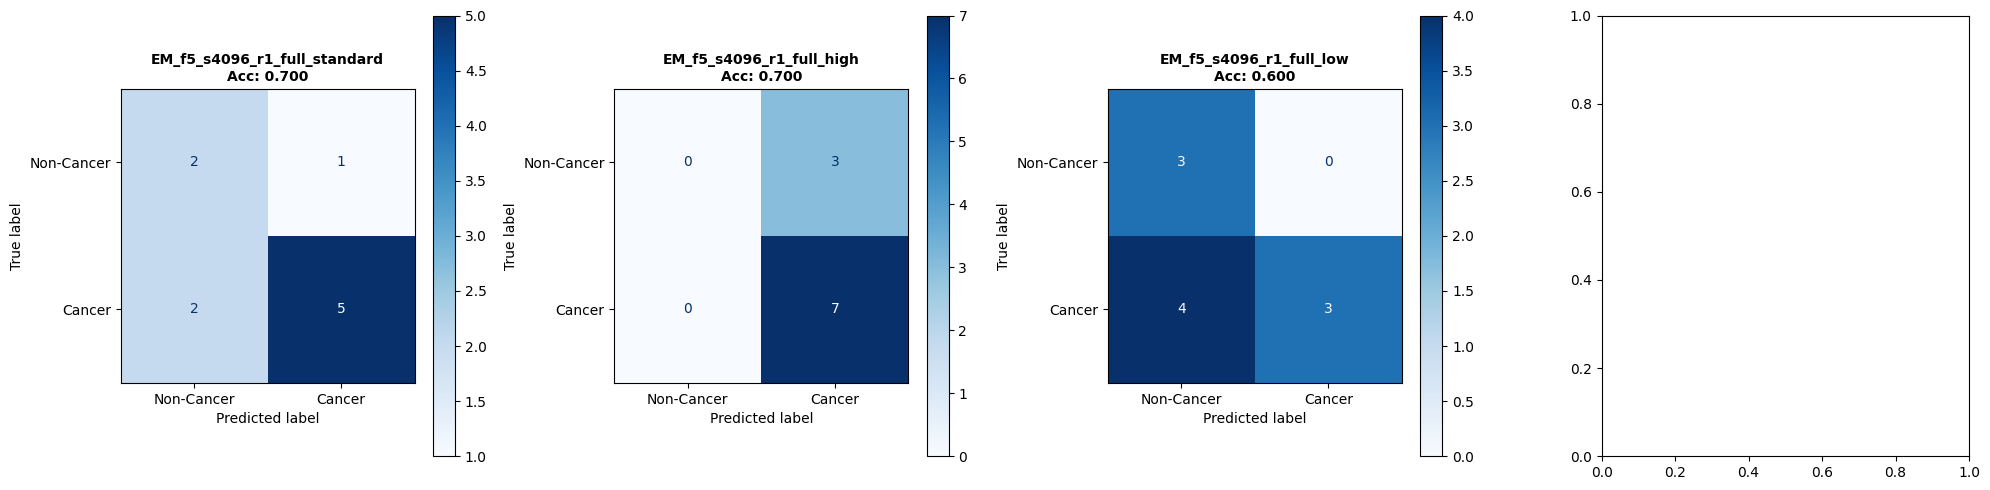

✓ Confusion matrices saved: em_qsvm_lungcancer_confusion_matrices.png


In [13]:
# ===================================================================
# CONFUSION MATRICES FOR TOP EXPERIMENTS
# ===================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("\nGenerating confusion matrices for top experiments...")

# Get top 4 experiments by test accuracy
top_experiments = results_df.nlargest(4, 'test_acc')

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, (_, result) in enumerate(top_experiments.iterrows()):
    y_test = np.array(result['y_test'])
    y_pred = np.array(result['y_pred'])
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Cancer', 'Cancer'])
    
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f"{result['experiment_id']}\nAcc: {result['test_acc']:.3f}", 
                        fontsize=10, fontweight='bold')
    axes[idx].grid(False)

plt.tight_layout()
plt.savefig('em_qsvm_lungcancer_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrices saved: em_qsvm_lungcancer_confusion_matrices.png")